<a href="https://colab.research.google.com/github/aakashkumar089/Class-notes/blob/main/OTS3_z_score.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.DataFrame({
    "Age":[22,23,15,26,35,40,47,62,55,32],
    "Salary":[12000,18000,55000,76000,25000,46000,36000,55000,43000,1657000]
})

In [3]:
data

,Age,Salary
0,22,12000
1,23,18000
2,15,55000
3,26,76000
4,35,25000
5,40,46000
6,47,36000
7,62,55000
8,55,43000
9,32,1657000


In [4]:
mean = data.mean()

print(mean)

Age           35.7
Salary    202300.0
dtype: float64


In [5]:
std = data.std()
print(std)

Age           15.261062
Salary    511487.601674
dtype: float64


In [6]:
Z_score = (data - mean)/std

print(Z_score)

        Age    Salary
0 -0.897710 -0.372052
1 -0.832183 -0.360322
2 -1.356393 -0.287984
3 -0.635605 -0.246927
4 -0.045868 -0.346636
5  0.281763 -0.305579
6  0.740447 -0.325130
7  1.723340 -0.287984
8  1.264656 -0.311444
9 -0.242447  2.844057


In [7]:
threshold_val = 2

outlier = data[(np.abs(Z_score) > threshold_val).any(axis=1)]
print(outlier)

   Age   Salary
9   32  1657000


In [8]:
clean_data = data[(np.abs(Z_score) <= threshold_val).all(axis=1)]


In [9]:
clean_data

,Age,Salary
0,22,12000
1,23,18000
2,15,55000
3,26,76000
4,35,25000
5,40,46000
6,47,36000
7,62,55000
8,55,43000


In [10]:
from scipy.stats import zscore

In [11]:
z_scores = np.abs(zscore(data))

In [12]:
z_scores

array([[0.9462689 , 0.39217727],
       [0.87719818, 0.37981225],
       [1.42976396, 0.30356128],
       [0.66998601, 0.26028371],
       [0.04834951, 0.36538639],
       [0.29700411, 0.32210882],
       [0.78049917, 0.34271719],
       [1.81656001, 0.30356128],
       [1.33306495, 0.32829133],
       [0.25556167, 2.99789952]])

In [13]:
threshhold = 2.5

outliers = data[(z_scores > threshhold).any(axis=1)]

In [14]:
print(outliers)

   Age   Salary
9   32  1657000


In [16]:
cleaned_data = data[(z_scores <= threshhold).all(axis=1)]

print(clean_data)


   Age  Salary
0   22   12000
1   23   18000
2   15   55000
3   26   76000
4   35   25000
5   40   46000
6   47   36000
7   62   55000
8   55   43000


In [17]:
# Box Plot and Inter Quartile Range for Detecting Outliers

data



,Age,Salary
0,22,12000
1,23,18000
2,15,55000
3,26,76000
4,35,25000
5,40,46000
6,47,36000
7,62,55000
8,55,43000
9,32,1657000


In [18]:
type(data)

pandas.core.frame.DataFrame

In [24]:
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)

In [25]:
print(Q1)
print(Q3)

Age          23.75
Salary    27750.00
Name: 0.25, dtype: float64
Age          45.25
Salary    55000.00
Name: 0.75, dtype: float64


In [26]:
IQR = Q3 - Q1

print(IQR)

Age          21.5
Salary    27250.0
dtype: float64


In [35]:
lower_bound = Q1 - 1.5*IQR

upper_bound = Q3 + 1.5*IQR

print(lower_bound)

print(upper_bound)

Age          -8.5
Salary   -13125.0
dtype: float64
Age          77.5
Salary    95875.0
dtype: float64


In [36]:
data[data > upper_bound]

,Age,Salary
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN
5,NaN,NaN
6,NaN,NaN
7,NaN,NaN
8,NaN,NaN
9,NaN,1657000.0


In [37]:
outliers = data[((data < lower_bound) | (data > upper_bound)).any(axis=1)]

print(outliers)

   Age   Salary
9   32  1657000


In [40]:
#Remove
df_clean = data[~((data < lower_bound) | (data > upper_bound)).any(axis=1)]

print(df_clean)

   Age  Salary
0   22   12000
1   23   18000
2   15   55000
3   26   76000
4   35   25000
5   40   46000
6   47   36000
7   62   55000
8   55   43000


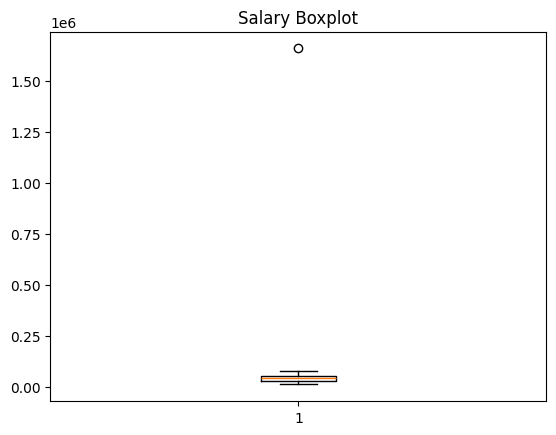

In [41]:
import matplotlib.pyplot as plt

plt.boxplot(data['Salary'])
plt.title("Salary Boxplot")
plt.show()